# Exploratory / Legacy Analysis

This notebook contains non-paper, exploratory, and legacy visualization cells moved out of `visualize_paper_figures.ipynb`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
from itertools import combinations

data_dir = "../data"
prompts_dir = "../prompts"
predictions_dir = "../predictions"
results_dir = "../results"

In [2]:
results = {}

for model in os.listdir(results_dir):
    df = pd.read_csv(os.path.join(results_dir, model))
    results[model.split('.csv')[0]] = df

In [3]:
models = [
    'gemini-2.0-flash',
    'claude-opus-4', 'claude-3.5-haiku',
    'llama-3.1-8b',  'llama-3.1-405b',
    'gpt-4o-mini', 'gpt-4o',
    'grok-3-mini', 'grok-3'
]
# cases = ['both', 'neither', 'pro', 'con']
stances = ['con', 'other', 'pro']
colors = {'con': 'royalblue', 'pro': 'orange', 'other': 'lightgray'}

remove_issues = [
    'corporal-punishment', 'dare-drug-abuse-resistance-education', 'tablets-vs-textbooks',
    # 'immigration', 'birth-control', 'golf',
]

In [8]:
m = models[0]

results[m][(results[m]['case'] == 'neither') & (results[m]['issue'] == 'artificial-intelligence-ai')]

,issue,issue_stance,count,case,model
64,artificial-intelligence-ai,pro,90,neither,gemini-2.0-flash


## All and none

In [ ]:
for model in models:
    df = results[model]
    cases_of_interest = ['neither', 'all']
    cases = df['case'].unique()
    df = df[df['case'].isin(cases_of_interest)]
    issues = df['issue'].unique()
    issues = issues[~np.isin(issues, remove_issues)]
    n_issues = len(issues)

    ncols = 4  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        cases = filtered['case'].unique()
        data = []
        for case in cases:
            sub = filtered[filtered['case'] == case]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            continue
        data_df = pd.DataFrame(data, columns=stances, index=cases)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Case')
        else:
            ax.set_yticklabels([])
        
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

    fig.suptitle(f"Model: {model}, Cases: {' and '.join(cases_of_interest)}", fontsize=32)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
    plt.savefig(f"../figures/{model}_neither_both_run2.png", dpi=300)

## Pro and Con

In [ ]:
for model in models:
    df = results[model]
    cases_of_interest = ['pro', 'con']
    cases = df['case'].unique()
    df = df[df['case'].isin(cases_of_interest)]
    issues = df['issue'].unique()
    issues = issues[~np.isin(issues, remove_issues)]
    n_issues = len(issues)

    ncols = 4  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        cases = filtered['case'].unique()
        data = []
        for case in cases:
            sub = filtered[filtered['case'] == case]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            continue
        data_df = pd.DataFrame(data, columns=stances, index=cases)
        left = pd.Series(l[0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Case')
        else:
            ax.set_yticklabels([])
        
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

    fig.suptitle(f"Model: {model}, Cases: {' and '.join(cases_of_interest)}", fontsize=32)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
    plt.savefig(f"../figures/{model}_pro_con_run2.png", dpi=300)

## 75 pro and 75 con

In [ ]:
for model in models:
    df = results[model]
    cases_of_interest = ['75pro', '75con']
    cases = df['case'].unique()
    df = df[df['case'].isin(cases_of_interest)]
    issues = df['issue'].unique()
    issues = issues[~np.isin(issues, remove_issues)]
    n_issues = len(issues)

    ncols = 4  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        cases = filtered['case'].unique()
        data = []
        for case in cases:
            sub = filtered[filtered['case'] == case]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            continue
        data_df = pd.DataFrame(data, columns=stances, index=cases)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Case')
        else:
            ax.set_yticklabels([])
        
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

    fig.suptitle(f"Model: {model}, Cases: {' and '.join(cases_of_interest)}", fontsize=32)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
    plt.savefig(f"../figures/{model}_overwhelming_pro_overwhelming_con_run2.png", dpi=300)

# Baseline analysis

## Calculate baselines

In [9]:
models = list(results.keys())
stances = ['con', 'other', 'pro']
full_run_models = ['claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'llama-3.1-405b', 'llama-3.1-8b']
part_run_models = [ 'gpt-4o-mini', 'gpt-4o', 'grok-3-mini', 'grok-3']

# Step 1: Aggregate and normalize to get shares
all_data = []
for model in full_run_models + part_run_models:
    df = results[model]
    for (issue, case), group in df.groupby(['issue', 'case']):
        counts = group.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
        total = counts.sum()
        if total > 0:
            shares = counts / total
        else:
            shares = counts
        for stance in stances:
            all_data.append({
                'model': model,
                'issue': issue,
                'case': case,
                'issue_stance': stance,
                'share': shares[stance]
            })

df_shares = pd.DataFrame(all_data)

# Step 2: Pivot so each model's share is a column
pivot = df_shares.pivot_table(
    index=['issue', 'case', 'issue_stance'],
    columns='model',
    values='share'
).reset_index()

# Step 3: Compute max difference between any two models for each row
def max_model_diff(row):
    shares = [row[model] for model in full_run_models if pd.notnull(row[model])]
    if len(shares) < 2:
        return np.nan
    return np.max(shares) - np.min(shares)

def diff_models_max(row):
    shares = [row[model] for model in full_run_models if pd.notnull(row[model])]
    if len(shares) < 2:
        return np.nan
    return full_run_models[np.argmax(shares)]

def diff_models_min(row):
    shares = [row[model] for model in full_run_models if pd.notnull(row[model])]
    if len(shares) < 2:
        return np.nan
    return full_run_models[np.argmin(shares)]

def average_model_diff(row):
    diffs = []
    for (model_1, model_2) in combinations(full_run_models, 2):
        diffs.append(abs(row[model_1] - row[model_2]))
    if len(diffs) < 2:
        return np.nan
    return np.mean(diffs)

def variance_model_diff(row):
    diffs = []
    for (model_1, model_2) in combinations(full_run_models, 2):
        diffs.append(abs(row[model_1] - row[model_2]))
    if len(diffs) < 2:
        return np.nan
    return np.var(diffs)

pivot['max_diff'] = pivot.apply(max_model_diff, axis=1)
pivot['diff_models_max'] = pivot.apply(diff_models_max, axis=1)
pivot['diff_models_min'] = pivot.apply(diff_models_min, axis=1)
pivot['average_model_diff'] = pivot.apply(average_model_diff, axis=1)
pivot['variance_model_diff'] = pivot.apply(variance_model_diff, axis=1)

# Step 4: Sort by largest difference
largest_diffs = pivot.sort_values('max_diff', ascending=False)

In [35]:
pivot.dropna()[pivot.dropna()['issue_stance'] == 'pro'][['issue', 'case', 'grok-3']]

model,issue,case,grok-3
164,binge-watching,75con,0.038889
167,binge-watching,75pro,0.827778
170,binge-watching,all,0.244444
173,binge-watching,con,0.000000
176,binge-watching,neither,0.311111
179,binge-watching,pro,1.000000
578,drones,75con,0.044444
581,drones,75pro,0.800000
584,drones,all,0.422222
587,drones,con,0.000000


In [ ]:
models = [
    'claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'gpt-4o', 'gpt-4o-mini',
    'grok-3', 'grok-3-mini', 'llama-3.1-405b', 'llama-3.1-8b'
]

neither_mask = (
    (pivot['case'] == 'neither') &
    (pivot['issue_stance'].isin(['pro', 'con']))
)
neither_mid = []
for model in models:
    mask = neither_mask & pivot[model].between(0.45, 0.55, inclusive='both')
    neither_mid.extend(
        pivot.loc[mask, ['issue', 'issue_stance', model]].assign(model=model).to_dict('records')
    )

results = []
for row in neither_mid:
    issue = row['issue']
    model = row['model']
    stance = row['issue_stance']

    pro_row = pivot[
        (pivot['issue'] == issue) &
        (pivot['case'] == 'pro') &
        (pivot['issue_stance'] == 'pro')
    ]
    con_row = pivot[
        (pivot['issue'] == issue) &
        (pivot['case'] == 'con') &
        (pivot['issue_stance'] == 'con')
    ]
    pro_val = pro_row[model].values[0] if not pro_row.empty else None
    con_val = con_row[model].values[0] if not con_row.empty else None

    pro_75_row = pivot[
        (pivot['issue'] == issue) &
        (pivot['case'] == '75pro') &
        (pivot['issue_stance'] == 'pro')
    ]
    con_75_row = pivot[
        (pivot['issue'] == issue) &
        (pivot['case'] == '75con') &
        (pivot['issue_stance'] == 'con')
    ]
    pro_75_val = pro_75_row[model].values[0] if not pro_75_row.empty else None
    con_75_val = con_75_row[model].values[0] if not con_75_row.empty else None

    if (pro_val is not None and pro_val > 0.9) and (con_val is not None and con_val > 0.9):
        results.append({
            'issue': issue,
            'model': model,
            'neither_stance': stance,
            'con_val': con_val,
            '75con_val': con_75_val,
            'neither_val': row[model],
            '75pro_val': pro_75_val,
            'pro_val': pro_val,
        })
pd.DataFrame(results)

In [ ]:
df_shares[
    (df_shares['case'] == 'neither')
    & (df_shares['issue_stance'].isin(['pro', 'con']))
    & (df_shares['share'] > 0.95)
]

In [36]:
def calculate_open_mindedness_scores(pivot_df, full_run_models, case_weights):
    """
    Calculate open-mindedness scores for each model according to the formula:
    OM_k(L) = Σ_{c∈C} w_c * |p_c - p_0| * I[s_c ≠ s_0]
    
    Args:
        pivot_df: DataFrame with model columns and case/issue/stance as index
        full_run_models: List of models to analyze
        case_weights: Dict mapping case names to weights (e.g., {'75con': 2, '75pro': 2, 'all': 3, 'pro': 1, 'con': 1})
    
    Returns:
        DataFrame with open-mindedness scores and analysis
    """        
    
    # Step 1: Identify baseline case for each issue
    baseline_case = 'neither'
    
    # Step 2: Calculate open-mindedness for each model-issue pair
    open_mindedness_data = []
    
    for model in full_run_models:
        if model not in pivot_df.columns:
            continue
            
        for issue in pivot_df['issue'].unique():
            issue_data = pivot_df[pivot_df['issue'] == issue]
            
            if issue_data.empty:
                continue
                
            # Get baseline case for this issue
            baseline_data = issue_data[issue_data['case'] == baseline_case]
            
            if baseline_data.empty:
                continue
                
            # Find baseline stance (stance with highest share for this model)
            baseline_stances = baseline_data[['issue_stance', model]].copy()
            baseline_stances = baseline_stances.sort_values(model, ascending=False)
            baseline_stance = baseline_stances.iloc[0]['issue_stance'] if baseline_stances.iloc[0]['issue_stance'] != 'other' else baseline_stances.iloc[1]['issue_stance']
            baseline_share = baseline_stances.iloc[0][model] if baseline_stances.iloc[0]['issue_stance'] != 'other' else baseline_stances.iloc[1][model]
            
            # Calculate open-mindedness score for this issue
            issue_score = 0
            stance_flips = []
            
            for case in issue_data['case'].unique():
                if case == baseline_case:
                    continue
                    
                case_data = issue_data[issue_data['case'] == case]
                if case_data.empty:
                    continue
                
                # Find the stance with highest share in this case for this model
                case_stances = case_data[['issue_stance', model]].copy()
                case_stances = case_stances.sort_values(model, ascending=False)
                case_stance = case_stances.iloc[0]['issue_stance']
                case_share = case_stances.iloc[0][model]
                
                # Check if stance flipped (s_c ≠ s_0)
                if case_stance != baseline_stance:
                    # Calculate magnitude of change: |p_c - p_0|
                    magnitude = abs(float(case_share) - float(baseline_share))
                    
                    # Apply case weight w_c
                    case_weight = case_weights.get(case, 1)
                    weighted_score = case_weight * magnitude
                    
                    # Add to issue score: w_c * |p_c - p_0| * I[s_c ≠ s_0]
                    issue_score += weighted_score
                    
                    stance_flips.append({
                        'case': case,
                        'from_stance': baseline_stance,
                        'to_stance': case_stance,
                        'magnitude': magnitude,
                        'weight': case_weight,
                        'weighted_score': weighted_score
                    })
            
            open_mindedness_data.append({
                'model': model,
                'issue': issue,
                'baseline_stance': baseline_stance,
                'baseline_share': baseline_share,
                'open_mindedness_score': issue_score,
                'num_stance_flips': len(stance_flips),
                'stance_flips': stance_flips
            })
    
    out_df = pd.DataFrame(open_mindedness_data)
    out_df['open_mindedness_score'] = out_df['open_mindedness_score'] / 9 * 100
    return out_df


case_weights = {
    'pro': 1,      # 100% one-sided pro arguments
    'con': 1,      # 100% one-sided con arguments  
    '75pro': 2,    # 75% one-sided pro arguments
    '75con': 2,    # 75% one-sided con arguments
    'all': 3,      # 50-50 split (clear and convincing)
    'neither': 0   # Baseline (no points)
}

# Then run the analysis
open_mindedness_df = calculate_open_mindedness_scores(pivot, full_run_models, case_weights)
print(open_mindedness_df.groupby('model')['open_mindedness_score'].mean().sort_values(ascending=False).to_latex())


\begin{tabular}{lr}
\toprule
 & open_mindedness_score \\
model &  \\
\midrule
claude-opus-4 & 7.143281 \\
gemini-2.0-flash & 6.250000 \\
llama-3.1-8b & 5.395893 \\
claude-3.5-haiku & 5.378680 \\
llama-3.1-405b & 5.191714 \\
\bottomrule
\end{tabular}



In [39]:
open_mindedness_df[
    (open_mindedness_df['model'] == 'grok-3')
]

,model,issue,baseline_stance,baseline_share,open_mindedness_score,num_stance_flips,stance_flips


In [45]:
subset_open_mindedness_df[
    (subset_open_mindedness_df['model'] == 'grok-3')
]

,model,issue,baseline_stance,baseline_share,open_mindedness_score,num_stance_flips,stance_flips
80,grok-3,binge-watching,con,0.688889,6.543210,2,"[{'case': '75pro', 'from_stance': 'con', 'to_s..."
81,grok-3,drones,pro,0.566667,13.827160,3,"[{'case': '75con', 'from_stance': 'pro', 'to_s..."
82,grok-3,fighting-in-hockey,pro,0.588889,25.679012,4,"[{'case': '75con', 'from_stance': 'pro', 'to_s..."
83,grok-3,olympics,con,0.544444,5.432099,2,"[{'case': '75pro', 'from_stance': 'con', 'to_s..."
84,grok-3,ronald-reagan,pro,1.000000,16.790123,3,"[{'case': '75con', 'from_stance': 'pro', 'to_s..."
85,grok-3,saturday-halloween,pro,0.877778,2.839506,2,"[{'case': '75con', 'from_stance': 'pro', 'to_s..."
86,grok-3,school-uniforms,pro,0.844444,6.913580,2,"[{'case': '75con', 'from_stance': 'pro', 'to_s..."
87,grok-3,standardized-tests,con,0.711111,13.148148,3,"[{'case': '75pro', 'from_stance': 'con', 'to_s..."
88,grok-3,teacher-tenure,pro,0.577778,14.444444,3,"[{'case': '75con', 'from_stance': 'pro', 'to_s..."
89,grok-3,us-penny,con,0.944444,0.185185,1,"[{'case': 'pro', 'from_stance': 'con', 'to_sta..."


In [40]:
# Then run the analysis
subset_open_mindedness_df = calculate_open_mindedness_scores(
    pivot.dropna(), full_run_models+part_run_models, case_weights
)
print(subset_open_mindedness_df.groupby('model')['open_mindedness_score'].mean().sort_values(ascending=False).to_latex())

\begin{tabular}{lr}
\toprule
 & open_mindedness_score \\
model &  \\
\midrule
grok-3 & 10.580247 \\
gpt-4o-mini & 9.401235 \\
gpt-4o & 7.759259 \\
claude-opus-4 & 7.740741 \\
gemini-2.0-flash & 7.598765 \\
claude-3.5-haiku & 7.055556 \\
llama-3.1-405b & 6.574074 \\
llama-3.1-8b & 6.314815 \\
grok-3-mini & 5.672840 \\
\bottomrule
\end{tabular}



In [44]:
subset_open_mindedness_df[
    (subset_open_mindedness_df['model'] == 'grok-3') &
    (subset_open_mindedness_df['issue'] == 'drones')
].stance_flips.values[0]

[{'case': '75con',
  'from_stance': 'pro',
  'to_stance': 'con',
  'magnitude': 0.38888888888888895,
  'weight': 2,
  'weighted_score': 0.7777777777777779},
 {'case': 'all',
  'from_stance': 'pro',
  'to_stance': 'con',
  'magnitude': 0.011111111111111072,
  'weight': 3,
  'weighted_score': 0.033333333333333215},
 {'case': 'con',
  'from_stance': 'pro',
  'to_stance': 'con',
  'magnitude': 0.43333333333333335,
  'weight': 1,
  'weighted_score': 0.43333333333333335}]

In [ ]:
top_12 = largest_diffs[(largest_diffs['case'] == 'neither') & (largest_diffs['issue_stance'] == 'pro')][:12]

# Prepare LaTeX table with issue, max model, min model, max model pro share, min model pro share
latex_rows = []
for _, row in top_12.iterrows():
    issue = row['issue']
    max_model = row['diff_models_max']
    min_model = row['diff_models_min']
    max_model_share = row[max_model] if pd.notnull(max_model) else np.nan
    min_model_share = row[min_model] if pd.notnull(min_model) else np.nan
    diff = row['max_diff']
    latex_rows.append(f"{issue.replace('-', ' ').title()} & {max_model.replace('-', ' ').title()} & {min_model.replace('-', ' ').title()} & {max_model_share*100:.1f}\% & {min_model_share*100:.1f}\% & {diff*100:.1f}\% \\\\")

latex_table = (
    "\\begin{tabular}{l l l r r}\n"
    "\\textbf{Issue} & \\textbf{Max Model} & \\textbf{Min Model} & \\textbf{Max Model Pro Share} & \\textbf{Min Model Pro Share} & \\textbf{Difference} \\\\\n"
    "\\hline\n" +
    "\n".join(latex_rows) +
    "\n\\end{tabular}"
)

print(latex_table)


In [ ]:
opus_undecided = pivot[(pivot['case'] == 'neither')][['issue', 'issue_stance', 'claude-opus-4']]
opus_undecided_pivot = opus_undecided.pivot(index='issue', columns='issue_stance', values='claude-opus-4').reset_index()
cols = ['issue', 'con', 'other', 'pro']
opus_undecided_pivot = opus_undecided_pivot.reindex(columns=cols)
issues_where_opus_is_highly_undecided = opus_undecided_pivot[opus_undecided_pivot['other'] == opus_undecided_pivot[['con', 'other', 'pro']].max(axis=1)]['issue'].to_list()

In [ ]:
opus_undecided_pivot.sort_values(by='other', ascending=False)

## Most different baselines

In [ ]:
base = pivot[
    # only consider neither cases
    (pivot['case'] == 'neither')
    # ignore cases where it's a highly undecided issue for opus
    & ~(pivot['issue'].isin(issues_where_opus_is_highly_undecided))
]

base_w_opus = pivot[
    # only consider neither cases
    (pivot['case'] == 'neither')
]

top_k = 25

for df in [base, base_w_opus]:
    print('\n\n\n')
    highest_average_model_diff_issues = df.sort_values(by='average_model_diff', ascending=False)[:top_k][['issue', 'average_model_diff']].groupby('issue').first()
    highest_variance_model_diff_issues = df.sort_values(by='variance_model_diff', ascending=False)[:top_k][['issue', 'variance_model_diff']].groupby('issue').first()
    highest_max_model_diff_issues = df.sort_values(by='max_diff', ascending=False)[:top_k][['issue', 'max_diff']].groupby('issue').first()

    print("BASELINE CASE (NO EVIDENCE); EXCLUDING THE FOLLOWING HIGHLY UNDECIDED TOPICS FOR OPUS:")
    for issue in sorted(issues_where_opus_is_highly_undecided, key=lambda x: x[0]):
        print(f"- {issue}")
    print()
    print('=' * 100)
    print("Issues with the highest average model disagreement (by average pairwise difference):")
    print('=' * 100)
    for issue, row in highest_average_model_diff_issues.iterrows():
        print(f"- {issue}: {row['average_model_diff']:.2f}")
    print()
    print('=' * 100)
    print("Issues with the highest variance in model disagreement (by variance of pairwise differences):")
    print('=' * 100)
    for issue, row in highest_variance_model_diff_issues.iterrows():
        print(f"- {issue}: {row['variance_model_diff']:.2f}")
    print()
    print('=' * 100)
    print("Issues with the highest maximum model disagreement (by max difference of pairwise differences):")
    print('=' * 100)
    for issue, row in highest_max_model_diff_issues.iterrows():
        print(f"- {issue}: {row['max_diff']:.2f}")
    print()

    all_issues = list(set(highest_average_model_diff_issues.index.tolist() + highest_variance_model_diff_issues.index.tolist() + highest_max_model_diff_issues.index.tolist()))

    print('=' * 100)
    print("All issues:")
    print('=' * 100)
    for issue in all_issues:
        print(f"- {issue}")
    print('=' * 100)

In [ ]:
# --- Model Open-Mindedness Metric (Pro Share) ---

openmindedness_results = {}
non_baseline_cases = ['pro', '75pro', 'all', '75con', 'con']
baseline_case = 'neither'

for model in models:
    df = results[model]
    # Compute baseline pro/con share for each issue
    baseline = df[df['case'] == baseline_case].groupby('issue').apply(
        lambda g: g.set_index('issue_stance')['count'] / g['count'].sum()
    ).unstack().fillna(0)
    # Compute pro share for each non-baseline case
    shifts = []
    for case in non_baseline_cases:
        case_df = df[df['case'] == case].groupby('issue').apply(
            lambda g: g.set_index('issue_stance')['count'] / g['count'].sum()
        ).unstack().fillna(0)
        for issue in baseline.index:
            if issue in case_df.index:
                baseline_pro = baseline.loc[issue].get('pro', 0)
                case_pro = case_df.loc[issue].get('pro', 0)
                shift = case_pro - baseline_pro
                shifts.append({'model': model, 'issue': issue, 'case': case, 'shift': shift, 'baseline_pro': baseline_pro, 'baseline_con': baseline.loc[issue].get('con', 0)})
    openmindedness_results[model] = pd.DataFrame(shifts)

In [ ]:
threshold = 0.3

for model in models:
    issues = openmindedness_results[model]['issue'].unique()
    print('-' * 100)
    print(f"Model: {model}")
    for issue in issues:
        shifts = openmindedness_results[model][(openmindedness_results[model]['issue'] == issue)]['shift'].to_list()
        if (all(abs(shift) < threshold for shift in shifts)):
            print(f"{issue} has all shifts < {threshold}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration
case_order = ['con', '75con', 'all', '75pro', 'pro']
baseline_case = 'neither'
buckets = ['Positive (pro > 0.75)', 'Middle', 'Negative (con > 0.75)']
models = ['claude-opus-4', 'claude-3.5-haiku', 'llama-3.1-405b', 'llama-3.1-8b', 
          'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini', 'gemini-2.0-flash']

# Create figure with 4 columns: Overall + 3 buckets
n_models = len(models)
fig, axes = plt.subplots(n_models, 4, figsize=(20, 2.2 * n_models), 
                        gridspec_kw={'width_ratios': [1, 1, 1, 1]})

# Ensure axes is 2D even for single row
if n_models == 1:
    axes = axes.reshape(1, -1)

for i, model in enumerate(models):
    print(f"Processing {model}...")
    df = results[model]
    
    # Compute baseline shares (same for all plots)
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue',
        columns='issue_stance',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    
    # COLUMN 0: Overall plot (from first script)
    avg_shifts_overall = []
    for case in case_order:
        case_df = df[df['case'] == case].pivot_table(
            index='issue',
            columns='issue_stance',
            values='count',
            aggfunc='sum',
            fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        shifts = []
        for issue in baseline.index:
            if issue in case_df.index:
                baseline_pro = baseline.loc[issue].get('pro', 0)
                case_pro = case_df.loc[issue].get('pro', 0)
                shift = case_pro - baseline_pro
                shifts.append(shift)
        avg_shifts_overall.append(np.mean(shifts) if shifts else 0)
    
    ax_overall = axes[i, 0]
    bars = ax_overall.barh(case_order, avg_shifts_overall, 
                          color=['royalblue' if v < 0 else 'orange' for v in avg_shifts_overall])
    ax_overall.invert_yaxis()
    ax_overall.set_xlim(-1.02, 1.02)
    ax_overall.set_xticks(np.linspace(-1.00, 1.00, 5))
    
    # Labels and titles
    if i == 0:
        ax_overall.set_title('Overall', fontsize=16)
    if i == n_models - 1:
        ax_overall.set_xlabel('Mean Pro Share Shift', fontsize=16)
    ax_overall.set_ylabel(f"{model}", fontsize=14, rotation=90)
    ax_overall.set_yticks(np.arange(len(case_order)))
    ax_overall.set_yticklabels(case_order, fontsize=16)
    ax_overall.tick_params(axis='x', labelsize=16)
    
    # COLUMNS 1-3: Bucket plots (from second script)
    # First, bucket the issues
    issue_buckets = {}
    for issue in baseline.index:
        pro_share = baseline.loc[issue].get('pro', 0)
        con_share = baseline.loc[issue].get('con', 0)
        if pro_share > 0.75:
            issue_buckets[issue] = 'Positive (pro > 0.75)'
        elif con_share > 0.75:
            issue_buckets[issue] = 'Negative (con > 0.75)'
        else:
            issue_buckets[issue] = 'Middle'
    
    for j, bucket in enumerate(buckets):
        bucket_issues = [issue for issue, b in issue_buckets.items() if b == bucket]
        avg_shifts = []
        
        for case in case_order:
            case_df = df[df['case'] == case].pivot_table(
                index='issue',
                columns='issue_stance',
                values='count',
                aggfunc='sum',
                fill_value=0
            )
            case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
            shifts = []
            for issue in bucket_issues:
                if issue in case_df.index and issue in baseline.index:
                    baseline_pro = baseline.loc[issue].get('pro', 0)
                    case_pro = case_df.loc[issue].get('pro', 0)
                    shift = case_pro - baseline_pro
                    shifts.append(shift)
            avg_shifts.append(np.mean(shifts) if shifts else 0)
        
        ax = axes[i, j + 1]  # +1 because column 0 is overall
        bars = ax.barh(case_order, avg_shifts, 
                      color=['royalblue' if v < 0 else 'orange' for v in avg_shifts])
        ax.invert_yaxis()
        ax.set_xlim(-1.05, 1.05)
        ax.set_xticks(np.linspace(-1.00, 1.00, 5))
        
        # Labels and titles
        if i == 0:
            ax.set_title(bucket, fontsize=16)
        if i == n_models - 1:
            ax.set_xlabel('Mean Pro Share Shift', fontsize=16)
    
        ax.set_yticks(np.arange(len(case_order)))
        ax.set_yticklabels([])
        
        ax.tick_params(axis='x', labelsize=16)
        
        # Add issue count annotation
        # n_issues = len(bucket_issues)
        # ax.text(0.02, 0.98, f'n={n_issues}', transform=ax.transAxes, 
        #        fontsize=8, verticalalignment='top', alpha=0.7)

# Add vertical line at x=0 for all subplots
for i in range(n_models):
    for j in range(4):
        axes[i, j].axvline(x=0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)

# Add legend
orange_patch = plt.Rectangle((0, 0), 1, 1, color='orange', label='Pro shift')
blue_patch = plt.Rectangle((0, 0), 1, 1, color='royalblue', label='Con shift')
fig.legend(handles=[orange_patch, blue_patch], loc='upper center', 
          bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Make room for legend
plt.suptitle('Mean Pro Share Shift by Evidence Case and Baseline Bucket', 
            y=0.98, fontsize=32, fontweight='bold')

# Save with high DPI for publication
plt.savefig('../figures/combined_pro_share_shift.pdf', bbox_inches='tight', dpi=300)
# plt.savefig('../figures/combined_pro_share_shift.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
results

In [ ]:
case_order = ['con', '75con', 'all', '75pro', 'pro']
case_labels = ['OS con', 'C&C con', 'Balanced', 'C&C pro', 'OS pro']
baseline_case = 'neither'

import math

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 38,
    'axes.labelsize': 32,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28
})

n_cols = 5
n_rows = math.ceil(len(models) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(36, 6 * n_rows), sharex=True)

axes = np.array(axes).reshape(-1)

for i, model in enumerate(['claude-opus-4', 'llama-3.1-405b', 'gpt-4o', 'grok-3', 'gemini-2.0-flash', 'claude-3.5-haiku', 'llama-3.1-8b', 'gpt-4o-mini', 'grok-3-mini']):
    print(model)
    df = results[model]
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue',
        columns='issue_stance',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    avg_shifts = []
    for case in case_order:
        case_df = df[df['case'] == case].pivot_table(
            index='issue',
            columns='issue_stance',
            values='count',
            aggfunc='sum',
            fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        shifts = []
        for issue in baseline.index:
            if issue in case_df.index:
                baseline_pro = baseline.loc[issue].get('pro', 0)
                case_pro = case_df.loc[issue].get('pro', 0)
                shift = case_pro - baseline_pro
                shifts.append(shift)
        avg_shifts.append(np.mean(shifts) if shifts else 0)
    ax = axes[i]
    bars = ax.barh(case_labels, avg_shifts, color=['royalblue' if v < 0 else 'orange' for v in avg_shifts])
    ax.set_title(f"{model}", fontsize=38)
    ax.invert_yaxis()
    max_abs = max(abs(min(avg_shifts)), abs(max(avg_shifts)), 0.1)
    ax.set_xlim(-1.02, 1.02)
    ax.set_xticks(np.linspace(-1.00, 1.00, 5))
    ax.tick_params(axis='x', labelsize=28)
    ax.tick_params(axis='y', labelsize=28)
    if i > 3:
        ax.tick_params(axis='x', labelbottom=True)
    ax.set_yticks(np.arange(len(case_labels)))
    if i % n_cols == 0:
        ax.set_yticklabels(case_labels, fontsize=28)
    else:
        ax.set_yticklabels([])

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

fig.text(0.04, 0.5, 'Argument Case', va='center', rotation='vertical', fontsize=36)
fig.text(0.5, 0.04, 'Mean Pro Share Shift', ha='center', fontsize=36)

plt.tight_layout(rect=[0.06, 0.06, 1, 1])
plt.savefig('../figures/pro_share_shift_by_evidence_case.pdf', bbox_inches='tight')
plt.show()

In [ ]:
case_order = ['con', '75con', 'all', '75pro', 'pro']
case_labels = ['OS con', 'C&C con', 'Balanced', 'C&C pro', 'OS pro']
baseline_case = 'neither'

import math

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 38,
    'axes.labelsize': 32,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28
})

n_cols = 3
n_rows = math.ceil(len(models) / n_cols)
# Make subplots wider and shorter by adjusting figsize
fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 6 * n_rows), sharex=True)

axes = np.array(axes).reshape(-1)

for i, model in enumerate(['claude-opus-4', 'llama-3.1-405b', 'gpt-4o', 'claude-3.5-haiku', 'llama-3.1-8b', 'gpt-4o-mini', 'grok-3',  'grok-3-mini', 'gemini-2.0-flash']):
    print(model)
    df = results[model]
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue',
        columns='issue_stance',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    avg_shifts = []
    for case in case_order:
        case_df = df[df['case'] == case].pivot_table(
            index='issue',
            columns='issue_stance',
            values='count',
            aggfunc='sum',
            fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        shifts = []
        for issue in baseline.index:
            if issue in case_df.index:
                baseline_pro = baseline.loc[issue].get('pro', 0)
                case_pro = case_df.loc[issue].get('pro', 0)
                shift = case_pro - baseline_pro
                shifts.append(shift)
        avg_shifts.append(np.mean(shifts) if shifts else 0)
    ax = axes[i]
    bars = ax.barh(case_labels, avg_shifts, color=['royalblue' if v < 0 else 'orange' for v in avg_shifts])
    ax.set_title(f"{model}", fontsize=38)
    ax.invert_yaxis()
    max_abs = max(abs(min(avg_shifts)), abs(max(avg_shifts)), 0.1)
    ax.set_xlim(-1.02, 1.02)
    ax.set_xticks(np.linspace(-1.00, 1.00, 5))
    ax.tick_params(axis='x', labelsize=28)
    ax.tick_params(axis='y', labelsize=28)
    if i > 5:
        ax.tick_params(axis='x', labelbottom=True)
    ax.set_yticks(np.arange(len(case_labels)))
    if i % n_cols == 0:
        ax.set_yticklabels(case_labels, fontsize=28)
    else:
        ax.set_yticklabels([])

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

fig.text(0.04, 0.5, 'Argument Case', va='center', rotation='vertical', fontsize=36)
fig.text(0.5, 0.04, 'Mean Pro Share Shift', ha='center', fontsize=36)

plt.tight_layout(rect=[0.06, 0.06, 1, 1])
plt.savefig('../figures/pro_share_shift_by_evidence_case.pdf', bbox_inches='tight')
plt.show()

In [ ]:

case_order = ['con', '75con', 'all', '75pro', 'pro']
baseline_case = 'neither'
buckets = ['Positive (pro > 0.75)', 'Middle', 'Negative (con > 0.75)']

n_models = len(models)
fig, axes = plt.subplots(n_models, 3, figsize=(18, 2 * n_models), sharey=True)

for i, model in enumerate(['claude-opus-4', 'claude-3.5-haiku', 'llama-3.1-405b', 'llama-3.1-8b',  'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini',  'gemini-2.0-flash']):
    df = results[model]
    # Compute baseline shares
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue',
        columns='issue_stance',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    # Bucket issues
    issue_buckets = {}
    for issue in baseline.index:
        pro_share = baseline.loc[issue].get('pro', 0)
        con_share = baseline.loc[issue].get('con', 0)
        if pro_share > 0.75:
            issue_buckets[issue] = 'Positive (pro > 0.75)'
        elif con_share > 0.75:
            issue_buckets[issue] = 'Negative (con > 0.75)'
        else:
            issue_buckets[issue] = 'Middle'
    for j, bucket in enumerate(buckets):
        bucket_issues = [issue for issue, b in issue_buckets.items() if b == bucket]
        avg_shifts = []
        for case in case_order:
            case_df = df[df['case'] == case].pivot_table(
                index='issue',
                columns='issue_stance',
                values='count',
                aggfunc='sum',
                fill_value=0
            )
            case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
            shifts = []
            for issue in bucket_issues:
                if issue in case_df.index and issue in baseline.index:
                    baseline_pro = baseline.loc[issue].get('pro', 0)
                    case_pro = case_df.loc[issue].get('pro', 0)
                    shift = case_pro - baseline_pro  # signed difference
                    shifts.append(shift)
            avg_shifts.append(np.mean(shifts) if shifts else 0)
        ax = axes[i, j] if n_models > 1 else axes[j]
        ax.barh(case_order, avg_shifts, color=['royalblue' if v < 0 else 'orange' for v in avg_shifts])
        ax.invert_yaxis()
        # max_abs = max(abs(min(avg_shifts)), abs(max(avg_shifts)), 0.1)
        ax.set_xlim(-1.05, 1.05)
        if i == 0:
            ax.set_title(bucket)
        if j == 0:
            ax.set_ylabel(f"{model}\n\nEvidence Case")
        else:
            ax.set_ylabel("")
        ax.set_xlabel('Mean Pro Share Shift (Signed)')
        ax.set_yticks(np.arange(len(case_order)))
        ax.set_yticklabels(case_order)
plt.tight_layout()
plt.suptitle('Signed Pro Share Shift by Evidence Case\n(by Baseline Bucket, per Model)', y=1.02, fontsize=18)
plt.savefig('../figures/pro_share_shift_by_evidence_case_by_baseline_bucket.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Calculate the effect of going from unanimous evidence (pro/con) to clear and convincing (75pro/75con)
# For each model, compute the mean pro share shift for (pro - 75pro) and (con - 75con) across all issues (no bucketing)
from sys import path
path.append('../')
from utils.utils import most_disagreed_upon_issues

most_disagreed_upon_issues = [issue.replace('.json', '') for issue in most_disagreed_upon_issues[:1]]
print(most_disagreed_upon_issues)

effect_results = []

for model in ['claude-opus-4', 'claude-3.5-haiku', 'llama-3.1-405b', 'llama-3.1-8b',  'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini',  'gemini-2.0-flash']:
    df = results[model]
    df = df[df['issue'].isin(most_disagreed_upon_issues)]
    for unanimous_case, partial_case, direction in [('pro', '75pro', 'Δ(One-sided pro →\nClear and convincing pro)'), ('con', '75con', 'Δ(One-sided con →\nClear and convincing con)')]:
        # Get pro shares for both cases
        unanimous_df = df[df['case'] == unanimous_case].pivot_table(
            index='issue',
            columns='issue_stance',
            values='count',
            aggfunc='sum',
            fill_value=0
        )
        partial_df = df[df['case'] == partial_case].pivot_table(
            index='issue',
            columns='issue_stance',
            values='count',
            aggfunc='sum',
            fill_value=0
        )
        unanimous_df = unanimous_df.div(unanimous_df.sum(axis=1), axis=0).fillna(0)
        partial_df = partial_df.div(partial_df.sum(axis=1), axis=0).fillna(0)
        # Only consider issues present in both
        common_issues = unanimous_df.index.intersection(partial_df.index)
        shifts = []
        for issue in common_issues:
            pro_unanimous = unanimous_df.loc[issue].get('pro', 0)
            pro_partial = partial_df.loc[issue].get('pro', 0)
            shift = pro_partial - pro_unanimous  # effect of adding one piece of contradictory evidence
            shifts.append(shift)
        mean_shift = np.mean(shifts) if shifts else 0
        effect_results.append({
            'model': model,
            'direction': direction,
            'mean_pro_share_shift': mean_shift
        })

# Convert to DataFrame for display
effect_df = pd.DataFrame(effect_results)
# display(effect_df)

# Optionally, plot the results vertically with narrow bars
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

bar_width = 0.3

models = effect_df['model'].unique()
y = np.arange(len(models))

# Make the figure wider by increasing the figsize
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
bar_width = 0.5 
for i, (direction, color) in enumerate(zip(['Δ(One-sided pro →\nClear and convincing pro)', 'Δ(One-sided con →\nClear and convincing con)'], ['royalblue', 'orange'])):
    subset = effect_df[effect_df['direction'] == direction].set_index('model').reindex(models)
    ax.barh(y, subset['mean_pro_share_shift'], height=bar_width, label=direction, color=color)

# Add vertical dotted lines at +/- 0.25 with label "evidence proportion"
# ax.axvline(0.25, color='gray', linestyle='dotted', lw=1.5, label='Pro/con evidence proportion')
# ax.axvline(-0.25, color='gray', linestyle='dotted', lw=1.5)

ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlabel('Mean Pro Share Shift\n(One-sided → Clear and convincing)')
# ax.set_title('Mean Pro Share Shift (Unanimous - Clear and Convincing)', pad=20)
ax.axvline(0, color='black', lw=0.8)
# Place legend outside the axis on the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # leave space for legend and suptitle
# plt.suptitle('Effect of Adding One Piece of Contradictory Argument\n(One-sided vs Clear and convincing)', y=1.04, fontsize=16)
plt.savefig('../figures/effect_of_adding_one_piece_of_contradictory_evidence.pdf', bbox_inches='tight')
plt.show()


In [ ]:
baseline_case = 'neither'
evidence_cases = ['pro', 'con']

# Collect all such rows in a list of dicts
unexpected_shifts = []

for model in models:
    df = results[model]
    # Compute baseline pro share
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    baseline_pro = baseline.get('pro', pd.Series(0, index=baseline.index))

    for case in evidence_cases:
        case_df = df[df['case'] == case].pivot_table(
            index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        case_pro = case_df.get('pro', pd.Series(0, index=case_df.index))

        # Only keep issues present in both
        common_issues = baseline_pro.index.intersection(case_pro.index)
        for issue in common_issues:
            shift = case_pro[issue] - baseline_pro[issue]
            if (case == 'pro' and shift < 0) or (case == 'con' and shift > 0):
                unexpected_shifts.append({
                    'model': model,
                    'issue': issue,
                    'evidence_case': case,
                    'baseline_pro': baseline_pro[issue],
                    'evidence_pro': case_pro[issue],
                    'shift': shift
                })

# Convert to DataFrame for easy viewing/sorting
unexpected_df = pd.DataFrame(unexpected_shifts)
print(unexpected_df.sort_values(['model', 'evidence_case', 'shift']).round(3).to_csv(sep='\t', index=False))

In [ ]:
# Get both count and mean for each model
grouped = unexpected_df.groupby(['model'])
count_df = grouped.count().add_suffix('_count')
mean_df = grouped['shift'].apply(lambda x: x.abs().mean()).to_frame().add_suffix('_mean')
result_df = pd.concat([count_df, mean_df], axis=1)
print(result_df[['shift_count', 'shift_mean']].sort_values(by='shift_mean', ascending=False).to_latex())


In [ ]:
top2_abs_shift = unexpected_df.loc[unexpected_df.groupby('model')['shift'].apply(lambda x: x.abs().nlargest(2)).reset_index(level=0, drop=True).index]
print(top2_abs_shift.round(3).to_csv(sep='\t', index=False))

In [ ]:
!uv pip install jinja2

In [ ]:
import pandas as pd
import numpy as np

evidence_cases = ['con', '75con', 'all', '75pro', 'pro']
baseline_case = 'neither'

top_openminded = {}

for model in models:
    df = results[model]
    # Compute baseline pro share
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    baseline_pro = baseline.get('pro', pd.Series(0, index=baseline.index))
    # Compute mean absolute shift for each issue
    abs_shifts = []
    for case in evidence_cases:
        case_df = df[df['case'] == case].pivot_table(
            index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        case_pro = case_df.get('pro', pd.Series(0, index=case_df.index))
        for issue in baseline_pro.index.intersection(case_pro.index):
            shift = abs(case_pro[issue] - baseline_pro[issue])
            abs_shifts.append({'issue': issue, 'case': case, 'shift': shift})
    # Aggregate by issue
    abs_shifts_df = pd.DataFrame(abs_shifts)
    mean_shift = abs_shifts_df.groupby('issue')['shift'].mean()
    top5 = mean_shift.sort_values(ascending=False).head(5)
    top_openminded[model] = top5
    print(f"\nTop 5 most open-minded issues for {model}:")
    print(top5)

In [ ]:
# Get issues in the 'neither' category where all model pro shares are in a middle range (e.g., between 0.4 and 0.6)
neither_df = pivot[(pivot['case'] == 'neither') & (pivot['issue_stance'] == 'pro')].copy()
model_cols = ['claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'llama-3.1-405b', 'llama-3.1-8b']
# For each row, check if all model pro shares are within [0.4, 0.6]
in_middle = neither_df[model_cols].apply(lambda row: ((row >= 0.3) & (row <= 0.7)).all(), axis=1)
middle_issues = neither_df[in_middle]
print(middle_issues[['issue'] + model_cols])

In [ ]:
pivot[(pivot['issue'] == 'historical-statue-removal') & (pivot['issue_stance'].isin(['pro', 'con']))][['case', 'issue_stance', 'claude-3.5-haiku']]

In [ ]:
baseline_hi_average_diff_issues = ['school-uniforms', 'binge-watching', 'gig-economy']

In [ ]:
baseline_hi_average_diff_issues = ['school-uniforms', 'binge-watching', 'gig-economy']

In [ ]:
models = list(results.keys())
model_pairs = list(combinations(models, 2))

for (model1, model2) in model_pairs:
    # Get pro_share for all (case, issue) tuples for each model
    def get_pro_share_vector(model, cases):
        df = results[model]
        df_filtered = df[
            (df['issue_stance'].isin(['pro', 'con', 'other']))
            & (df['case'].isin(cases))
        ]
        stance_counts = df_filtered.pivot_table(
            index=['case', 'issue'],
            columns='issue_stance',
            values='count',
            fill_value=0
        )
        stance_counts['total'] = stance_counts.sum(axis=1)
        stance_counts['pro_share'] = stance_counts['pro'] / stance_counts['total']
        return stance_counts['pro_share']

    # For each model pair, plot a single figure with a subfigure (subplot) for each case set
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
    case_sets = [['neither', 'all'], ['75pro', '75con'], ['pro', 'con']]
    for i, cases in enumerate(case_sets):
        pro_share1 = get_pro_share_vector(model1, cases)
        pro_share2 = get_pro_share_vector(model2, cases)

        # Find common (case, issue) tuples
        common_tuples = pro_share1.index.intersection(pro_share2.index)
        pro_share1 = pro_share1.loc[common_tuples]
        pro_share2 = pro_share2.loc[common_tuples]

        # Compute outliers
        diff = (pro_share1 - pro_share2).abs()
        outliers = diff.sort_values(ascending=False)
        top_outlier_indices = outliers.head(10).index

        # Print the top 10 outliers
        print(f"Top 10 outliers for {model1} vs {model2} (most disagreement) for cases {cases}:")
        for idx in top_outlier_indices:
            print(f"{idx}: {model1}={pro_share1[idx]:.2f}, {model2}={pro_share2[idx]:.2f}, diff={diff[idx]:.2f}")

        # Scatterplot in subfigure
        ax = axes[i]
        ax.scatter(pro_share1, pro_share2, alpha=0.5, label='All points')
        # Highlight top 10 outliers in red
        ax.scatter(pro_share1.loc[top_outlier_indices], pro_share2.loc[top_outlier_indices], color='red', label='Top 10 outliers')
        ax.set_xlabel(f"Pro Share ({model1})")
        if i == 0:
            ax.set_ylabel(f"Pro Share ({model2})")
        ax.set_title(f"Cases: {', '.join(cases)}")
        # Annotate with Pearson correlation
        corr = np.corrcoef(pro_share1, pro_share2)[0, 1]
        ax.text(0.05, 0.95, f"Pearson r = {corr:.2f}", transform=ax.transAxes, fontsize=12, va='top')
        ax.legend()
        ax.grid(True)

    plt.suptitle(f"Pro Share Agreement: {model1} vs {model2} (by case set)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    os.makedirs('../figures', exist_ok=True)
    plt.savefig(f'../figures/pro_share_scatter_{model1}_vs_{model2}_subfigs.png', dpi=300)
    plt.show()

In [ ]:
stances = ['con', 'other', 'pro']
colors = {'con': 'royalblue', 'pro': 'orange', 'other': 'lightgray'}

df = pd.concat(results.values())
cases_of_interest = ['neither']
df = df[df['case'].isin(cases_of_interest)]
issues = df['issue'].unique()
# issues = issues[~np.isin(issues, remove_issues)]

# Define the desired model order for the plots
ordered_models = ['llama-3.1-8b', 'llama-3.1-405b', 'claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

# Split issues into those WITH and WITHOUT all gpt/grok models
gpt_grok_models = ['gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

issues_with_gpt_grok = []
issues_without_gpt_grok = []

for issue in issues:
    filtered = df[df['issue'] == issue]
    models_present = set(filtered['model'].unique())
    if all(m in models_present for m in gpt_grok_models):
        issues_with_gpt_grok.append(issue)
    else:
        issues_without_gpt_grok.append(issue)

# Concatenate so that issues with gpt/grok are at the top
ordered_issues = issues_with_gpt_grok + issues_without_gpt_grok
n_issues = len(ordered_issues)

ncols = 5  # Adjust as needed for readability
nrows = math.ceil(n_issues / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

for idx, issue in enumerate(ordered_issues):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]
    filtered = df[df['issue'] == issue]
    models_present = set(filtered['model'].unique())
    # Only plot bars for models that have data for this issue
    models_to_plot = [m for m in ordered_models if m in models_present]
    data = []
    for model in models_to_plot:
        sub = filtered[filtered['model'] == model]
        counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
        shares = counts / counts.sum() if counts.sum() > 0 else counts
        data.append(shares.values)
    if len(data) == 0:
        ax.axis('off')
        continue
    data_df = pd.DataFrame(data, columns=stances, index=models_to_plot)
    left = pd.Series([0]*len(data_df), index=data_df.index)
    for stance in stances:
        ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
        left += data_df[stance]
    ax.set_title(issue)
    ax.set_xlabel('Share')
    ax.set_xlim(0, 1)
    if col == 0:
        ax.set_ylabel('Model')
    else:
        ax.set_yticklabels([])
    ax.legend().set_visible(False)

# Hide any unused subplots
for idx in range(n_issues, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].axis('off')

handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
labels = [stance.capitalize() for stance in stances]
fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

fig.suptitle(f"Baseline stances with no evidence for all models (all issues)", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
plt.savefig(f"../figures/neither_all_models.pdf")

In [ ]:
stances = ['con', 'other', 'pro']
colors = {'con': 'royalblue', 'pro': 'orange', 'other': 'lightgray'}


# Filtered version: only issues where max pairwise difference < 0.05
df = pd.concat(results.values())
cases_of_interest = ['neither']
df = df[df['case'].isin(cases_of_interest)]
issues = df['issue'].unique()

# Define the desired model order for the plots
ordered_models = ['llama-3.1-8b', 'llama-3.1-405b', 'claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

# Function to calculate max pairwise difference for an issue
def calculate_max_pairwise_diff(issue_data):
    """Calculate the maximum pairwise difference in pro share between any two models for an issue"""
    models_present = set(issue_data['model'].unique())
    models_to_check = [m for m in ordered_models if m in models_present]
    
    if len(models_to_check) < 2:
        return 0
    
    pro_shares = {}
    for model in models_to_check:
        model_data = issue_data[issue_data['model'] == model]
        counts = model_data.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
        total = counts.sum()
        if total > 0:
            pro_shares[model] = counts.get('pro', 0) / total
        else:
            pro_shares[model] = 0
    
    # Calculate pairwise differences
    max_diff = 0
    for i, model1 in enumerate(models_to_check):
        for model2 in models_to_check[i+1:]:
            diff = abs(pro_shares[model1] - pro_shares[model2])
            max_diff = max(max_diff, diff)
    
    return max_diff

# Filter issues based on max pairwise difference
filtered_issues = []
for issue in issues:
    issue_data = df[df['issue'] == issue]
    max_diff = calculate_max_pairwise_diff(issue_data)
    if max_diff < 0.1:  # Only include issues with low disagreement
        filtered_issues.append(issue)

print(f"Original number of issues: {len(issues)}")
print(f"Number of issues with max pairwise difference < 0.1: {len(filtered_issues)}")
print(f"Filtered out {len(issues) - len(filtered_issues)} issues")

# Split filtered issues into those WITH and WITHOUT all gpt/grok models
gpt_grok_models = ['gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

issues_with_gpt_grok = []
issues_without_gpt_grok = []

for issue in filtered_issues:
    filtered = df[df['issue'] == issue]
    models_present = set(filtered['model'].unique())
    if all(m in models_present for m in gpt_grok_models):
        issues_with_gpt_grok.append(issue)
    else:
        issues_without_gpt_grok.append(issue)

# Concatenate so that issues with gpt/grok are at the top
ordered_issues = issues_with_gpt_grok + issues_without_gpt_grok
n_issues = len(ordered_issues)

double_unanimous_issues = {}

if n_issues == 0:
    print("No issues meet the criteria (max pairwise difference < 0.1)")
else:
    ncols = 5  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(ordered_issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        models_present = set(filtered['model'].unique())
        # Only plot bars for models that have data for this issue
        models_to_plot = [m for m in ordered_models if m in models_present]
        data = []
        for model in models_to_plot:
            sub = filtered[filtered['model'] == model]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            # if shares['pro'] > 0.9 or shares['con'] > 0.9:
            if issue not in double_unanimous_issues:
                double_unanimous_issues[issue] = [{
                    'model': model,
                    'pro_share': shares['pro'],
                    'con_share': shares['con']
                }]
            else:
                double_unanimous_issues[issue].append({
                    'model': model,
                    'pro_share': shares['pro'],
                    'con_share': shares['con']
                })
            data.append(shares.values)
        if len(data) == 0:
            ax.axis('off')
            continue
        data_df = pd.DataFrame(data, columns=stances, index=models_to_plot)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Model')
        else:
            ax.set_yticklabels([])
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]

    fig.suptitle(f"Baseline stances with no evidence - High Agreement Issues (max pairwise diff < 0.1)", fontsize=32, y=1.08)

    # Move legend above the title, outside the plot area
    fig.legend(
        handles, labels, title='Stance',
        loc='upper center',
        bbox_to_anchor=(0.5, 1.04),  # move legend higher
        ncol=3,
        fontsize=20,
        title_fontsize=24,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])  # Leave more space at the top for legend and suptitle
    plt.savefig(f"../figures/neither_all_models_high_agreement.pdf", bbox_inches='tight')
    plt.show()

    near_unanimous_issues = filtered_issues.copy()

In [ ]:
# Calculate the average pro and con share across models per issue
avg_shares = {}
for issue, model_list in double_unanimous_issues.items():
    pro_shares = [float(model['pro_share']) for model in model_list]
    con_shares = [float(model['con_share']) for model in model_list]
    avg_pro = sum(pro_shares) / len(pro_shares) if pro_shares else 0
    avg_con = sum(con_shares) / len(con_shares) if con_shares else 0
    avg_shares[issue] = {'avg_pro_share': avg_pro, 'avg_con_share': avg_con}


df_avg_shares = pd.DataFrame(avg_shares).T * 100
df_avg_shares.index = df_avg_shares.index.str.replace('-', ' ').str.title()
df_avg_shares.columns = ['Average pro share', 'Average con share']
df_avg_shares['Average pro share'] = df_avg_shares['Average pro share'].astype(float)
df_avg_shares['Average con share'] = df_avg_shares['Average con share'].astype(float)
df_avg_shares['Average pro share'] = df_avg_shares['Average pro share'].round(1)
df_avg_shares['Average con share'] = df_avg_shares['Average con share'].round(1)
df_avg_shares = df_avg_shares.sort_values(by='Average pro share', ascending=False)
df_avg_shares['Average pro share'] = df_avg_shares['Average pro share'].astype(str) + '\%'
df_avg_shares['Average con share'] = df_avg_shares['Average con share'].astype(str) + '\%'
df_avg_shares['Average pro share'] = df_avg_shares['Average pro share'].str.replace('.0', '')
df_avg_shares['Average con share'] = df_avg_shares['Average con share'].str.replace('.0', '')
df_avg_shares['Average pro share'] = df_avg_shares['Average pro share'].str.replace('nan', '')
df_avg_shares['Average con share'] = df_avg_shares['Average con share'].str.replace('nan', '')
print(df_avg_shares.round(1).to_latex())

In [ ]:
# Filtered version: only issues where Claude Opus 4 has "other" proportion > 0.3
df = pd.concat([r for m, r in results.items() if m in ['gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']])
cases_of_interest = ['neither']
df = df[df['case'].isin(cases_of_interest)]
issues = df['issue'].unique()

# Define the desired model order for the plots
ordered_models = ['llama-3.1-8b', 'llama-3.1-405b', 'claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

# Function to calculate Claude Opus 4 "other" proportion for an issue
def calculate_opus_other_proportion(issue_data):
    """Calculate the proportion of 'other' stance for Claude Opus 4 on an issue"""
    opus_data = issue_data[issue_data['model'] == 'claude-opus-4']
    if len(opus_data) == 0:
        return 0
    
    counts = opus_data.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
    total = counts.sum()
    if total > 0:
        return counts.get('other', 0) / total
    else:
        return 0

# Filter issues based on Claude Opus 4 "other" proportion
filtered_issues = []
for issue in issues:
    issue_data = df[df['issue'] == issue]
    opus_other_prop = calculate_opus_other_proportion(issue_data)
    if opus_other_prop > 0.3:  # Only include issues where Opus is highly undecided
        filtered_issues.append(issue)

print(f"Original number of issues: {len(issues)}")
print(f"Number of issues where Claude Opus 4 has 'other' proportion > 0.3: {len(filtered_issues)}")
print(f"Filtered out {len(issues) - len(filtered_issues)} issues")

n_issues = len(filtered_issues)

if n_issues == 0:
    print("No issues meet the criteria (Claude Opus 4 'other' proportion > 0.3)")
else:
    ncols = 5  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(filtered_issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        models_present = set(filtered['model'].unique())
        # Only plot bars for models that have data for this issue
        models_to_plot = [m for m in ordered_models if m in models_present]
        data = []
        for model in models_to_plot:
            sub = filtered[filtered['model'] == model]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            ax.axis('off')
            continue
        data_df = pd.DataFrame(data, columns=stances, index=models_to_plot)
        print(data)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Model')
        else:
            ax.set_yticklabels([])
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]

    fig.suptitle(f"Baseline stances with no evidence - Issues where Claude Opus 4 is highly undecided ('other' > 0.3)", fontsize=32, y=1.08)

    # Move legend above the title, outside the plot area
    fig.legend(
        handles, labels, title='Stance',
        loc='upper center',
        bbox_to_anchor=(0.5, 1.04),  # move legend higher
        ncol=3,
        fontsize=20,
        title_fontsize=24,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])  # Leave more space at the top for legend and suptitle
    plt.savefig(f"../figures/neither_all_models_opus_undecided.pdf", bbox_inches='tight')
    plt.show()

opus_filtered_issues = filtered_issues.copy()

In [ ]:
opus_filtered_issues

In [ ]:
# Filtered version: only issues where Claude Opus 4 has "other" proportion > 0.3
df = pd.concat([r for m, r in results.items() if m in ['claude-opus-4']])
cases_of_interest = ['neither', 'all']
df = df[df['case'].isin(cases_of_interest)]
issues = df['issue'].unique()

ordered_cases = ['all', 'neither']

def calculate_opus_other_proportion(issue_data):
    opus_data = issue_data[issue_data['case'] == 'neither']
    if len(opus_data) == 0:
        return 0
    counts = opus_data.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
    total = counts.sum()
    if total > 0:
        return counts.get('other', 0) / total
    else:
        return 0

filtered_issues = []
for issue in issues:
    issue_data = df[df['issue'] == issue]
    opus_other_prop = calculate_opus_other_proportion(issue_data)
    if opus_other_prop > 0.3:
        print(f"{issue} has {opus_other_prop} 'other' proportion")
        filtered_issues.append(issue)

print(f"Original number of issues: {len(issues)}")
print(f"Number of issues where Claude Opus 4 has 'other' proportion > 0.3: {len(filtered_issues)}")
print(f"Filtered out {len(issues) - len(filtered_issues)} issues")

n_issues = len(filtered_issues)

if n_issues == 0:
    print("No issues meet the criteria (Claude Opus 4 'other' proportion > 0.3)")
else:
    ncols = 4
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*7, nrows*3.5), squeeze=False)

    for idx, issue in enumerate(filtered_issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        cases_present = set(filtered['case'].unique())
        cases_to_plot = [c for c in ordered_cases if c in cases_present]
        data = []
        for case in cases_to_plot:
            sub = filtered[filtered['case'] == case]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            ax.axis('off')
            continue
        data_df = pd.DataFrame(data, columns=stances, index=cases_to_plot)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue, fontsize=30)
        ax.set_xlim(0, 1)
        ax.tick_params(axis='x', labelsize=22)
        if col == 0:
            ax.set_yticklabels(['Balanced', 'Baseline'], fontsize=24)
            ax.tick_params(axis='y', labelsize=24)
        else:
            ax.set_yticklabels([], fontsize=24)
            ax.tick_params(axis='y', labelsize=24)
        ax.legend().set_visible(False)
        if idx == 0:
            fig.text(-0.02, 0.5, 'Argument Case', va='center', rotation='vertical', fontsize=30)
            fig.text(0.5, -0.04, 'Share', ha='center', fontsize=30)

    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]

    fig.legend(
        handles, labels, title='Stance',
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),
        ncol=3,
        fontsize=24,
        title_fontsize=28,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(f"../figures/neither_all_models_opus_undecided.pdf", bbox_inches='tight')
    plt.show()

opus_filtered_issues = filtered_issues.copy()

In [ ]:
# Filtered version: only issues that have data for all GPT and Grok models
df = pd.concat(results.values())
cases_of_interest = ['neither']
df = df[df['case'].isin(cases_of_interest)]
issues = df['issue'].unique()

# Define the desired model order for the plots
ordered_models = ['llama-3.1-8b', 'llama-3.1-405b', 'claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

# Define GPT and Grok models
gpt_grok_models = ['gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

# Filter issues to only include those with data for all GPT and Grok models
filtered_issues = []
for issue in issues:
    filtered = df[df['issue'] == issue]
    models_present = set(filtered['model'].unique())
    if all(m in models_present for m in gpt_grok_models):
        filtered_issues.append(issue)

print(f"Original number of issues: {len(issues)}")
print(f"Number of issues with data for all GPT and Grok models: {len(filtered_issues)}")
print(f"Filtered out {len(issues) - len(filtered_issues)} issues")

# Use only the filtered issues
ordered_issues = filtered_issues
n_issues = len(ordered_issues)

if n_issues == 0:
    print("No issues have data for all GPT and Grok models")
else:
    ncols = 5  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*3.5), squeeze=False)

    for idx, issue in enumerate(ordered_issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        models_present = set(filtered['model'].unique())
        # Only plot bars for models that have data for this issue
        models_to_plot = [m for m in ordered_models if m in models_present]
        data = []
        for model in models_to_plot:
            sub = filtered[filtered['model'] == model]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            ax.axis('off')
            continue
        data_df = pd.DataFrame(data, columns=stances, index=models_to_plot)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue, fontsize=16)
        # ax.set_xlabel('Share', fontsize=16)
        ax.set_xlim(0, 1)
        if col == 0:
            # ax.set_ylabel('Model', fontsize=16)
            # Set yticklabels fontsize to 16 for model names
            ax.tick_params(axis='y', labelsize=16)
        else:
            ax.set_yticklabels([])
        ax.legend().set_visible(False)
        if idx == 0:
            fig.text(-0.02, 0.5, 'Model', va='center', rotation='vertical', fontsize=20)
            fig.text(0.5, -0.04, 'Share', ha='center', fontsize=20)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    # Keep legend in place, move title up by increasing y
    fig.legend(
        handles, labels, title='Stance',
        loc='upper center',
        bbox_to_anchor=(0.5, 1.12),
        ncol=3, fontsize=20, title_fontsize=24
    )

    # fig.suptitle(
    #     "Baseline stances with no arguments (Including GPT and Grok)",
    #     fontsize=32, y=1.08  # Move suptitle up to make more space for legend
    # )
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave even more space at the top for legend and suptitle
    plt.savefig(f"../figures/neither_all_models_gpt_grok_only.pdf", bbox_inches='tight')
    plt.show()

    grok_gpt_issues = filtered_issues.copy()

In [ ]:
# Use only the filtered issues
ordered_issues = filtered_issues
n_issues = len(ordered_issues)

if n_issues == 0:
    print("No issues have data for all GPT and Grok models")
else:
    ncols = 3  # Reduced from 4 for even better readability
    nrows = math.ceil(n_issues / ncols)

    # Much larger figure size and font sizes for LaTeX paper
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*10, nrows*7), squeeze=False)

    for idx, issue in enumerate(ordered_issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        models_present = set(filtered['model'].unique())
        # Only plot bars for models that have data for this issue
        models_to_plot = [m for m in ordered_models if m in models_present]
        data = []
        for model in models_to_plot:
            sub = filtered[filtered['model'] == model]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            ax.axis('off')
            continue
        data_df = pd.DataFrame(data, columns=stances, index=models_to_plot)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue, fontsize=28)  # Increased from 20, removed bold
        ax.set_xlim(0, 1)
        if col == 0:
            # Set yticklabels fontsize to 22 for model names (increased from 18)
            ax.tick_params(axis='y', labelsize=24)
        else:
            ax.set_yticklabels([])
        ax.legend().set_visible(False)
        # Increase x-axis tick label size significantly
        ax.tick_params(axis='x', labelsize=24)
        if idx == 0:
            fig.text(-0.01, 0.5, 'Model', va='center', rotation='vertical', fontsize=32)  # Increased from 24
            fig.text(0.5, -0.01, 'Share', ha='center', fontsize=32)  # Increased from 24

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    # Keep legend in place, move title up by increasing y
    fig.legend(
        handles, labels, title='Stance',
        loc='upper center',
        bbox_to_anchor=(0.5, 1.01),
        ncol=3, fontsize=28, title_fontsize=32,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"../figures/neither_all_models_gpt_grok_only.pdf", bbox_inches='tight', dpi=300)
    plt.show()

    grok_gpt_issues = filtered_issues.copy()

In [ ]:
plotted_issues = list(set(opus_filtered_issues + near_unanimous_issues + grok_gpt_issues))

ncols = 5  # Adjust as needed for readability
nrows = math.ceil(n_issues / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

ordered_issues = df[~df['issue'].isin(plotted_issues)]['issue'].unique()
n_issues = len(ordered_issues)

for idx, issue in enumerate(ordered_issues):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]
    filtered = df[df['issue'] == issue]
    models_present = set(filtered['model'].unique())
    # Only plot bars for models that have data for this issue
    models_to_plot = [m for m in ordered_models if m in models_present]
    data = []
    for model in models_to_plot:
        sub = filtered[filtered['model'] == model]
        counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
        shares = counts / counts.sum() if counts.sum() > 0 else counts
        data.append(shares.values)
    if len(data) == 0:
        ax.axis('off')
        continue
    data_df = pd.DataFrame(data, columns=stances, index=models_to_plot)
    left = pd.Series([0]*len(data_df), index=data_df.index)
    for stance in stances:
        ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
        left += data_df[stance]
    ax.set_title(issue)
    ax.set_xlabel('Share')
    ax.set_xlim(0, 1)
    if col == 0:
        ax.set_ylabel('Model')
    else:
        ax.set_yticklabels([])
    ax.legend().set_visible(False)

# Hide any unused subplots
for idx in range(n_issues, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].axis('off')

handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
labels = [stance.capitalize() for stance in stances]
# Keep legend in place, move title up by increasing y
fig.legend(
    handles, labels, title='Stance',
    loc='upper center',
    bbox_to_anchor=(0.5, .97),
    ncol=3, fontsize=20, title_fontsize=24
)

fig.suptitle(
    "Baseline stances with no evidence - Remaining issues",
    fontsize=32, y=1.00  # Move suptitle up to make more space for legend
)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave even more space at the top for legend and suptitle
plt.savefig(f"../figures/neither_remaining_issues.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# Claude Opus 4 stance distribution analysis (all stances, vertical bars, wide chart)
df = results['claude-opus-4']
cases_of_interest = ['neither']  # Baseline case with no evidence
df_filtered = df[df['case'].isin(cases_of_interest)]

stances = ['Pro/Con', 'other']
colors = {'Pro/Con': 'black', 'other': 'lightgray'}

# Calculate proportion of each stance for each issue
issue_stance_props = []
for issue in df_filtered['issue'].unique():
    issue_data = df_filtered[df_filtered['issue'] == issue]
    total_count = issue_data['count'].sum()
    stance_props = {}
    for stance in stances:
        if stance == 'Pro/Con':
            stance_count = issue_data[issue_data['issue_stance'].isin(['pro', 'con'])]['count'].sum()
        else:
            stance_count = issue_data[issue_data['issue_stance'] == stance]['count'].sum()
        stance_props[stance] = stance_count / total_count if total_count > 0 else 0
    stance_props['issue'] = issue
    issue_stance_props.append(stance_props)

# Convert to DataFrame and sort by "other" proportion (descending)
stance_df = pd.DataFrame(issue_stance_props)
stance_df = stance_df.sort_values('other', ascending=False).reset_index(drop=True)

# Plot: vertical bars, one group per issue, wide chart
fig, ax = plt.subplots(1, 1, figsize=(max(12, len(stance_df)*0.35), 8))

bar_width = .9
x = range(len(stance_df))
bottom = [0] * len(stance_df)
bars = []
for stance in stances:
    bar = ax.bar(x, stance_df[stance], bottom=bottom, color=colors.get(stance, 'gray'), width=bar_width, label=stance.capitalize(), alpha=0.85)
    bars.append(bar)
    bottom = [b + s for b, s in zip(bottom, stance_df[stance])]

# Customize the plot
ax.set_ylabel('Proportion', fontsize=14)
ax.set_xlabel('Issue', fontsize=14)
ax.set_title('Claude Opus 4: Other vs Pro/Con Distribution by Issue\n(Baseline case with no evidence)', fontsize=16, pad=20)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(stance_df['issue'], rotation=45, fontsize=9, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Stance', fontsize=12, title_fontsize=13)

# Add value labels for each stance segment if large enough
for stance_idx, stance in enumerate(stances):
    for i, val in enumerate(stance_df[stance]):
        if val > 0.05:
            y = sum(stance_df[s][i] for s in stances[:stance_idx]) + val / 2
            ax.text(i, y, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if stance != 'other' else 'black')

plt.tight_layout()
plt.savefig('../figures/claude_opus_4_all_stance_proportions.pdf', bbox_inches='tight')
plt.show()

# Print summary statistics for each stance
print(f"Total issues analyzed: {len(stance_df)}")
for stance in stances:
    print(f"Mean proportion of '{stance}' stance: {stance_df[stance].mean():.3f}")
    print(f"Median proportion of '{stance}' stance: {stance_df[stance].median():.3f}")
    print(f"Maximum proportion of '{stance}' stance: {stance_df[stance].max():.3f}")
    print(f"Minimum proportion of '{stance}' stance: {stance_df[stance].min():.3f}")

# Show top 10 issues with highest "other" proportion
print("\nTop 10 issues with highest 'other' stance proportion:")
print(stance_df.head(10)[['issue', 'other']].rename(columns={'other': 'other_proportion'}).to_string(index=False))

In [ ]:
# Claude Opus 4 stance distribution analysis (all stances, vertical bars, wide chart)
df = results['claude-opus-4']
cases_of_interest = ['neither']  # Baseline case with no evidence
df_filtered = df[~df['case'].isin(cases_of_interest)]

stances = ['Pro/Con', 'other']
colors = {'Pro/Con': 'black', 'other': 'lightgray'}

# Calculate proportion of each stance for each issue
issue_stance_props = []
for issue in df_filtered['issue'].unique():
    issue_data = df_filtered[df_filtered['issue'] == issue]
    total_count = issue_data['count'].sum()
    stance_props = {}
    for stance in stances:
        if stance == 'Pro/Con':
            stance_count = issue_data[issue_data['issue_stance'].isin(['pro', 'con'])]['count'].sum()
        else:
            stance_count = issue_data[issue_data['issue_stance'] == stance]['count'].sum()
        stance_props[stance] = stance_count / total_count if total_count > 0 else 0
    stance_props['issue'] = issue
    issue_stance_props.append(stance_props)

# Convert to DataFrame and preserve the issue order from the previous stance_df
previous_issue_order = stance_df['issue'].tolist()  # assumes stance_df is the previous cell's stance_df
stance_df = pd.DataFrame(issue_stance_props)
# Reindex to match the order of issues from the previous stance_df

stance_df = stance_df.set_index('issue').loc[previous_issue_order].reset_index()

# Plot: vertical bars, one group per issue, wide chart
fig, ax = plt.subplots(1, 1, figsize=(max(12, len(stance_df)*0.35), 8))

bar_width = 0.9
x = range(len(stance_df))
bottom = [0] * len(stance_df)
bars = []
for stance in stances:
    bar = ax.bar(x, stance_df[stance], bottom=bottom, color=colors.get(stance, 'gray'), width=bar_width, label=stance.capitalize(), alpha=0.85)
    bars.append(bar)
    bottom = [b + s for b, s in zip(bottom, stance_df[stance])]

# Customize the plot
ax.set_ylabel('Proportion', fontsize=14)
ax.set_xlabel('Issue', fontsize=14)
ax.set_title('Claude Opus 4: Other vs Pro/Con Distribution by Issue\n(Cases with evidence)', fontsize=16, pad=20)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(stance_df['issue'], rotation=45, fontsize=9, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Stance', fontsize=12, title_fontsize=13)

# Add value labels for each stance segment if large enough
for stance_idx, stance in enumerate(stances):
    for i, val in enumerate(stance_df[stance]):
        if val > 0.05:
            y = sum(stance_df[s][i] for s in stances[:stance_idx]) + val / 2
            ax.text(i, y, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if stance != 'other' else 'black')

plt.tight_layout()
plt.savefig('../figures/claude_opus_4_all_stance_proportions_with_evidence.pdf', bbox_inches='tight')
plt.show()

# Print summary statistics for each stance
print(f"Total issues analyzed: {len(stance_df)}")
for stance in stances:
    print(f"Mean proportion of '{stance}' stance: {stance_df[stance].mean():.3f}")
    print(f"Median proportion of '{stance}' stance: {stance_df[stance].median():.3f}")
    print(f"Maximum proportion of '{stance}' stance: {stance_df[stance].max():.3f}")
    print(f"Minimum proportion of '{stance}' stance: {stance_df[stance].min():.3f}")

# Show top 10 issues with highest "other" proportion
print("\nTop 10 issues with highest 'other' stance proportion:")
print(stance_df.head(10)[['issue', 'other']].rename(columns={'other': 'other_proportion'}).to_string(index=False))

In [ ]:
# non-Claude Opus 4 stance distribution analysis (all stances, vertical bars, wide chart)
df = pd.concat([r for m, r in results.items() if m != 'claude-opus-4'])
cases_of_interest = ['neither']  # Baseline case with no evidence
df_filtered = df[df['case'].isin(cases_of_interest)]

stances = ['Pro/Con', 'other']
colors = {'Pro/Con': 'black', 'other': 'lightgray'}

# Calculate proportion of each stance for each issue
issue_stance_props = []
for issue in df_filtered['issue'].unique():
    issue_data = df_filtered[df_filtered['issue'] == issue]
    total_count = issue_data['count'].sum()
    stance_props = {}
    for stance in stances:
        if stance == 'Pro/Con':
            stance_count = issue_data[issue_data['issue_stance'].isin(['pro', 'con'])]['count'].sum()
        else:
            stance_count = issue_data[issue_data['issue_stance'] == stance]['count'].sum()
        stance_props[stance] = stance_count / total_count if total_count > 0 else 0
    stance_props['issue'] = issue
    issue_stance_props.append(stance_props)

# Convert to DataFrame and preserve the issue order from the previous stance_df
previous_issue_order = stance_df['issue'].tolist()  # assumes stance_df is the previous cell's stance_df
stance_df = pd.DataFrame(issue_stance_props)
# Reindex to match the order of issues from the previous stance_df

stance_df = stance_df.set_index('issue').loc[previous_issue_order].reset_index()

# Plot: vertical bars, one group per issue, wide chart
fig, ax = plt.subplots(1, 1, figsize=(max(12, len(stance_df)*0.35), 8))

bar_width = 0.9
x = range(len(stance_df))
bottom = [0] * len(stance_df)
bars = []
for stance in stances:
    bar = ax.bar(x, stance_df[stance], bottom=bottom, color=colors.get(stance, 'gray'), width=bar_width, label=stance.capitalize(), alpha=0.85)
    bars.append(bar)
    bottom = [b + s for b, s in zip(bottom, stance_df[stance])]

# Customize the plot
ax.set_ylabel('Proportion', fontsize=14)
ax.set_xlabel('Issue', fontsize=14)
ax.set_title('All other models: Other vs Pro/Con Distribution by Issue\n(Baseline case with no evidence)', fontsize=16, pad=20)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(stance_df['issue'], rotation=45, fontsize=9, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Stance', fontsize=12, title_fontsize=13)

# Add value labels for each stance segment if large enough
for stance_idx, stance in enumerate(stances):
    for i, val in enumerate(stance_df[stance]):
        if val > 0.05:
            y = sum(stance_df[s][i] for s in stances[:stance_idx]) + val / 2
            ax.text(i, y, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if stance != 'other' else 'black')

plt.tight_layout()
plt.savefig('../figures/all_models_other_vs_procon_proportions.pdf', bbox_inches='tight')
plt.show()

# Print summary statistics for each stance
print(f"Total issues analyzed: {len(stance_df)}")
for stance in stances:
    print(f"Mean proportion of '{stance}' stance: {stance_df[stance].mean():.3f}")
    print(f"Median proportion of '{stance}' stance: {stance_df[stance].median():.3f}")
    print(f"Maximum proportion of '{stance}' stance: {stance_df[stance].max():.3f}")
    print(f"Minimum proportion of '{stance}' stance: {stance_df[stance].min():.3f}")

# Show top 10 issues with highest "other" proportion
print("\nTop 10 issues with highest 'other' stance proportion:")
print(stance_df.head(10)[['issue', 'other']].rename(columns={'other': 'other_proportion'}).to_string(index=False))

In [ ]:
# Calculate, for each model, the percentage of issues where the baseline pro count is greater than the con count
# Output as a LaTeX table

# Identify the baseline case (adjust as needed)
baseline_case = 'neither'
pro_stance = 'pro'
con_stance = 'con'

df = pd.concat(results.values())

# Filter to baseline case
baseline_df = df[df['case'] == baseline_case]

# For each model and issue, get pro and con counts
pivot = baseline_df.pivot_table(
    index=['model', 'issue'],
    columns='issue_stance',
    values='count',
    fill_value=0
).reset_index()

# Calculate for each model, the percentage of issues where pro > con
def pro_gt_con_pct(subdf):
    # Only consider issues where both pro and con counts are present (or at least one is present)
    valid = subdf[[pro_stance, con_stance]].notnull().all(axis=1)
    # If either is missing, treat as 0
    pro_counts = subdf[pro_stance].fillna(0)
    con_counts = subdf[con_stance].fillna(0)
    return (pro_counts > con_counts).mean() * 100

result = (
    pivot.groupby('model')
    .apply(lambda subdf: f"{((subdf[pro_stance].fillna(0) > subdf[con_stance].fillna(0)).mean() * 100):.1f}%")
    .reset_index(name='% Pro > Con')
)

# Format for LaTeX
latex_table = result.to_latex(
    index=False,
    float_format="%.1f",
    caption="Percentage of Issues Where Baseline Pro Count is Greater Than Con Count (by Model)",
    label="tab:baseline_pro_gt_con"
)

print(latex_table)




In [ ]:
models = ['claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'llama-3.1-405b', 'llama-3.1-8b', 'gpt-4o', 'gpt-4o-mini', 'grok-3', 'grok-3-mini']

con = pivot[(pivot['case'] == 'con') & (pivot['issue_stance'] ==  'con')][['issue'] + models]
cc_con = pivot[(pivot['case'] == '75con') & (pivot['issue_stance'] ==  'con')][['issue'] + models]
pro = pivot[(pivot['case'] == 'pro') & (pivot['issue_stance'] ==  'pro')][['issue'] + models]
cc_pro = pivot[(pivot['case'] == '75pro') & (pivot['issue_stance'] ==  'pro')][['issue'] + models]

con_merge = con.merge(cc_con, on='issue', how='inner', suffixes=('-con', '-cc-con'))
pro_merge = pro.merge(cc_pro, on='issue', how='inner', suffixes=('-pro', '-cc-pro'))

for model in models:
    con_merge[f'{model}-diff'] = con_merge[f'{model}-con'] - con_merge[f'{model}-cc-con']
    pro_merge[f'{model}-diff'] = pro_merge[f'{model}-pro'] - pro_merge[f'{model}-cc-pro']

pro_con = pd.concat([pro_merge, con_merge])

In [ ]:
con_merge.sort_values(by='llama-3.1-405b-diff', ascending=False)[:3][['issue', 'llama-3.1-405b-con', 'llama-3.1-405b-cc-con', 'llama-3.1-405b-diff']]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='claude-3.5-haiku-diff', ascending=False)[:15]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='claude-opus-4-diff', ascending=False)[:4]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='gemini-2.0-flash-diff', ascending=False)[:5]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='llama-3.1-405b-diff', ascending=False)[:34]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='llama-3.1-8b-diff', ascending=False)[:11]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='gpt-4o-diff', ascending=False)[:1]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='gpt-4o-mini-diff', ascending=False)[:10]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='grok-3-diff', ascending=False)[:2]

In [ ]:
pro_con[['issue'] + [f'{model}-diff' for model in models]].sort_values(by='grok-3-mini-diff', ascending=False)[:1]

In [ ]:
high_level_topic_map = {
    'Digital Life, Science, & Technology': [
        'pokemon-go',
        'artificial-intelligence-AI',
        'binge-watching',
        'cell-phones',
        'internet',
        'net-neutrality',
        'social-media',
        'space-colonization',
        'tiktok',
        'video-games',
        'tablets-vs-textbooks'
    ], 'Government & Civics': [
        'american-socialism',
        'congressional-term-limits',
        'dc-and-puerto-rico-statehood',
        'filibuster',
        'mandatory-national-service',
        'sanctuary-cities',
        'us-supreme-court',
        'american-civil-liberties-union-aclu',
        'us-pledge-of-allegiance'
    ], 'Education': [
        'animal-dissection',
        'book-bans',
        'cell-phones',
        'college-education',
        'corporal-punishment',
        'free-college',
        'homework',
        'school-uniforms',
        'school-vaccine-mandates',
        'standardized-tests',
        'student-loan-debt',
        'school-vouchers',
        'teacher-tenure',
    ], 'Health & Medicine': [
        'abortion',
        'birth-control',
        'maid-medical-aid-in-dying',
        'medical-marijuana',
        'milk',
        'obesity',
        'prescription-drug-costs',
        'universal-health-care',
        'vaping',
        'employer-vaccine-mandates',
        'obamacare',
    ], 'Environment & Animal Rights': [
        'alternative-energy',
        'animal-dissection',
        'animal-testing',
        'cannabidiol-cbd-for-pets',
        'fracking',
        'fur-clothing-bans',
        'gmos',
        'pit-bull-bans',
        'single-use-plastics',
        'vegetarianism',
        'zoos',
        'climate-change',
        'dakota-access-pipeline',
        'fur-clothing-bans',
        'gmos',
        'pit-bull-bans',
        'single-use-plastics',
        'vegetarianism',
        'zoos',
        'climate-change',
        'dakota-access-pipeline'
    ], 'Elections & Presidents': [
        'election-day',
        'electoral-college',
        'felon-voting',
        'voting-age',
        'voting-machines',
        'bill-clinton',
        'ronald-reagan',
    ], 'Society & Holidays': [
        'cancel-culture',
        'daylight-saving-time',
        'dress-codes',
        'historical-statue-removal',
        'homelessness',
        'reparations-for-slavery',
        'sanctuary-cities',
        'santa-claus',
        'saturday-halloween',
        'gay-marriage',
        'ride-sharing',
    ], 'Sports': [
        'cheerleading',
        'fighting-in-hockey',
        'football',
        'golf',
        'national-anthem-protest',
        'olympics',
        'sports-and-drugs',
        'college-football-playoffs',
        'paying-college-athletes',
    ], 'Law & Order': [
        'constitutional-carry-of-guns',
        'death-penalty',
        'defund-the-police',
        'drinking-age',
        'gun-control',
        'police-body-cameras',
        'private-prisons',
        'recreational-marijuana-legalization',
        'dare-drug-abuse-resistance-education',
        'prostitution',
    ], 'Economy & Taxes': [
        'corporate-tax-rate',
        'gig-economy',
        'gold-standard',
        'minimum-wage',
        'social-security',
        'universal-basic-income-ubi',
        'us-penny',
        'big-three-auto',
        'churches-and-taxes',
        'insider-trading-by-congress',
    ], 'Immigration & International Scene': [
        'cuba-embargo',
        'immigration',
        'sanctuary-cities',
        'drones',
        'us-drone-shot-down-by-iran',
        'us-iraq-war',
        'wtc-muslim-center',
    ]
}

topic_high_level_map = {}
for key, value in high_level_topic_map.items():
    for v in value:
        topic_high_level_map[v] = key

In [ ]:
# open_mindedness_df = calculate_open_mindedness_scores(pivot, full_run_models, case_weights)
open_mindedness_df['high_level_topic'] = open_mindedness_df['issue'].map(topic_high_level_map)
score_col = [col for col in open_mindedness_df.columns if 'open_mindedness' in col][0]

In [ ]:
(
    open_mindedness_df.groupby(['high_level_topic'])[score_col]
    .agg(['mean', 'count'])
    .reset_index()
    .sort_values(by=['mean'], ascending=False)
)

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import matplotlib.image as mpimg

grouped = (
    open_mindedness_df.groupby(['high_level_topic', 'model'])[score_col]
    .agg(['mean', 'count'])
    .reset_index()
)

topics = grouped['high_level_topic'].unique()
models = grouped['model'].unique()

def get_logo_path(model):
    m = model.lower()
    if "haiku" in m:
        return "logos/claude-3.5.png"
    elif "opus" in m:
        return "logos/claude-4.png"
    elif "8b" in m:
        return "logos/llama-8.png"
    elif "405b" in m:
        return "logos/llama-405.png"
    elif "gemini" in m or "google" in m:
        return "logos/gemini.png"
    else:
        return None

# Order topics by maximum value descending
topic_max_values = grouped.groupby('high_level_topic')['mean'].max().sort_values(ascending=False)
topics = topic_max_values.index.tolist()

fig, ax = plt.subplots(figsize=(15, 0.6 * len(topics)))
y_pos = {topic: i for i, topic in enumerate(topics)}

# Set a smaller display size for all logos
LOGO_DISPLAY_SIZE = 35

for topic in topics:
    topic_data = grouped[grouped['high_level_topic'] == topic]
    if not topic_data.empty:
        means = topic_data.set_index('model').reindex(models)['mean']
        ax.plot(
            means,
            [y_pos[topic]] * len(models),
            color='gray',
            alpha=0.4,
            linewidth=1,
            zorder=0
        )

for topic in topics:
    topic_data = grouped[grouped['high_level_topic'] == topic]
    # Sort by mean so lowest is first, highest is last
    topic_data_sorted = topic_data.sort_values(by='mean', ascending=True)
    for _, row in topic_data_sorted.iterrows():
        model = row['model']
        x = row['mean']
        y = y_pos[row['high_level_topic']]
        logo_path = get_logo_path(model)
        if logo_path and os.path.exists(logo_path):
            try:
                arr = mpimg.imread(logo_path)
                img = OffsetImage(arr, zoom=1, resample=True)
                img.image.axes = ax
                img.set_zoom(LOGO_DISPLAY_SIZE / max(arr.shape[0], arr.shape[1]))
                ab = AnnotationBbox(img, (x, y), frameon=False, pad=0.0, box_alignment=(0.5,0.5))
                ax.add_artist(ab)
            except Exception:
                ax.scatter(x, y, color='gray', s=40)
        else:
            ax.scatter(x, y, color='gray', s=40)

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(topics, fontsize=14)
ax.set_xlabel('Open-mindedness', fontsize=14)
# ax.set_ylabel('High Level Topic')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(left=1.95, right=10.05)
plt.tight_layout()
plt.savefig('../figures/open_mindedness_by_topic_by_model.pdf')
plt.show()

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import matplotlib.image as mpimg

def get_logo_path(model_family):
    m = model_family.lower()
    if m == 'llama':
        return "logos/llama.png"
    elif m == 'claude':
        return "logos/claude.png"
    elif m == 'gemini':
        return "logos/gemini.png"
    else:
        return None

def get_model_family(model):
    m = model.lower()
    if "haiku" in m or "opus" in m:
        return "claude"
    elif "8b" in m or "405b" in m:
        return "llama"
    elif "gemini" in m or "google" in m:
        return "gemini"
    elif m == "llama":
        return "llama"
    elif m == "claude":
        return "claude"
    elif m == "gemini":
        return "gemini"
    else:
        return None

open_mindedness_df['model_family'] = open_mindedness_df['model'].apply(get_model_family)

grouped = (
    open_mindedness_df.groupby(['high_level_topic', 'model_family'])[score_col]
    .agg(['mean', 'count'])
    .reset_index()
)

topic_max_values = grouped.groupby('high_level_topic')['mean'].max().sort_values(ascending=False)
topics = topic_max_values.index.tolist()
model_families = ['llama', 'claude', 'gemini']

fig, ax = plt.subplots(figsize=(12, 0.6 * len(topics)))
y_pos = {topic: i for i, topic in enumerate(topics)}

LOGO_DISPLAY_SIZE = 35

for topic in topics:
    topic_data = grouped[grouped['high_level_topic'] == topic]
    if not topic_data.empty:
        means = topic_data.set_index('model_family').reindex(model_families)['mean']
        ax.plot(
            means,
            [y_pos[topic]] * len(model_families),
            color='gray',
            alpha=0.4,
            linewidth=1,
            zorder=0
        )

for model_family in model_families:
    data = grouped[grouped['model_family'] == model_family]
    logo_path = get_logo_path(model_family)
    for _, row in data.iterrows():
        x = row['mean']
        y = y_pos[row['high_level_topic']]
        if logo_path and os.path.exists(logo_path):
            try:
                arr = mpimg.imread(logo_path)
                img = OffsetImage(arr, zoom=1, resample=True)
                img.image.axes = ax
                img.set_zoom(LOGO_DISPLAY_SIZE / max(arr.shape[0], arr.shape[1]))
                ab = AnnotationBbox(img, (x, y), frameon=False, pad=0.0, box_alignment=(0.5,0.5))
                ax.add_artist(ab)
            except Exception:
                ax.scatter(x, y, color='gray', s=40)
        else:
            ax.scatter(x, y, color='gray', s=40)

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(topics)
ax.set_xlabel('Open-mindedness')
ax.set_ylabel('High Level Topic')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## Statistical Significance and Order Effects

These figures summarize the new reviewer-facing analyses:
- significance testing and confidence intervals (`results/statistical_summary.csv`)
- recency/order effects (`results/order_effects.csv`)

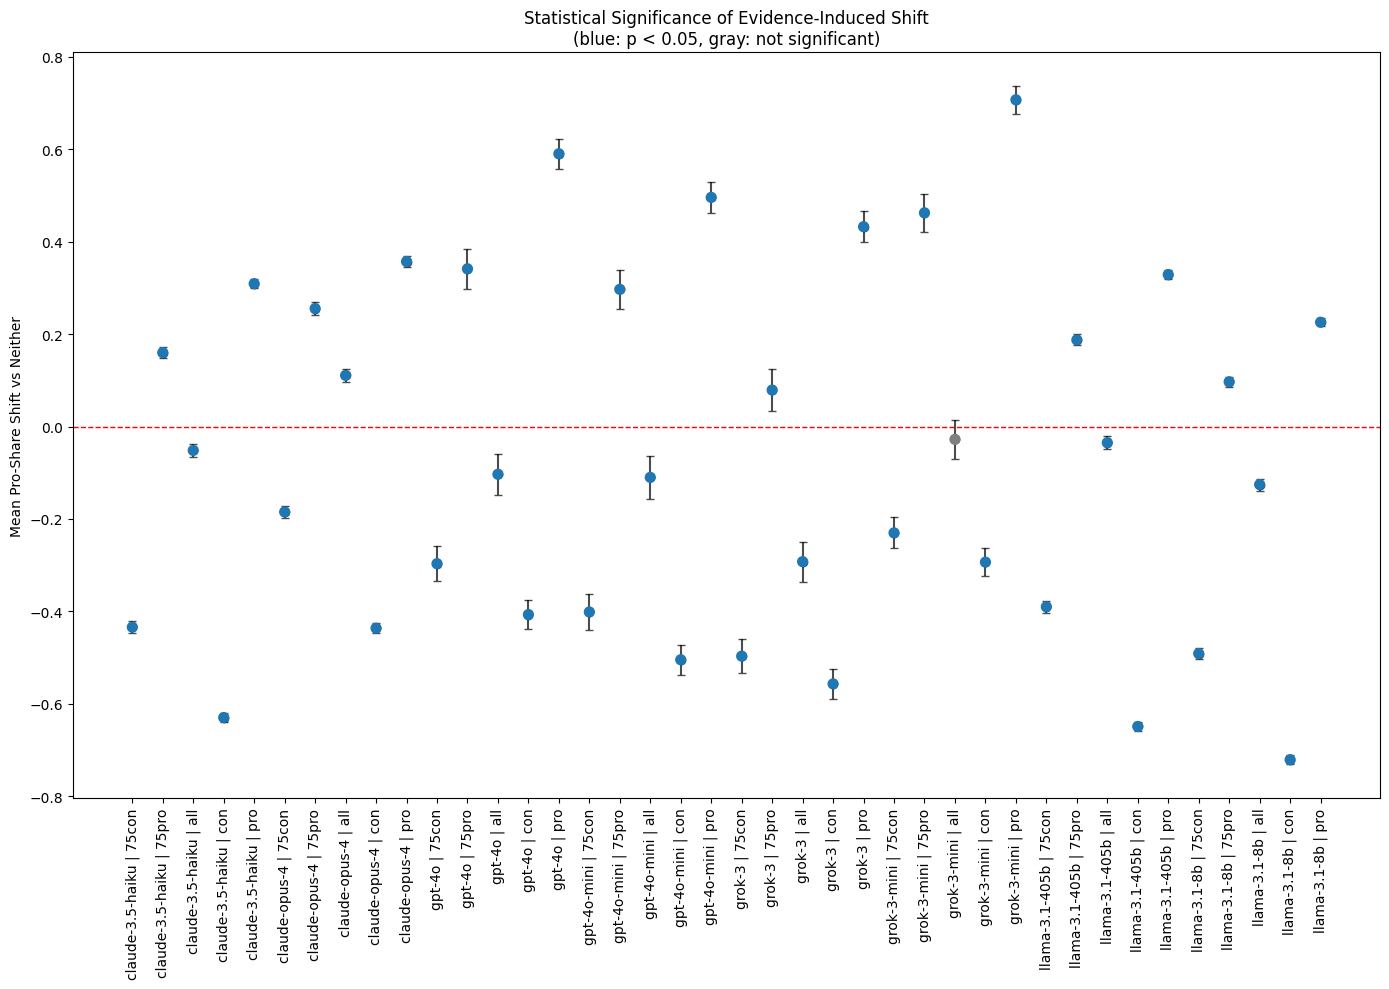

,model,case,mean_pro_shift,p_value
27,grok-3-mini,all,-0.027778,0.189326


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.read_csv('../results/statistical_summary.csv')

# Keep a stable order by model then evidence case
stats_df = stats_df.sort_values(['model', 'case']).reset_index(drop=True)

# Highlight statistically significant shifts
stats_df['significant'] = stats_df['p_value'] < 0.05
stats_df['label'] = stats_df['model'] + ' | ' + stats_df['case']

plt.figure(figsize=(14, 10))
ax = plt.gca()

# Plot mean shift with confidence intervals
x = range(len(stats_df))
means = stats_df['mean_pro_shift']
err_low = means - stats_df['ci_lower']
err_high = stats_df['ci_upper'] - means

colors = ['tab:blue' if sig else 'tab:gray' for sig in stats_df['significant']]

ax.errorbar(
    x,
    means,
    yerr=[err_low, err_high],
    fmt='o',
    capsize=3,
    color='black',
    ecolor='black',
    alpha=0.7,
)

ax.scatter(x, means, c=colors, s=50, zorder=3)
ax.axhline(0, linestyle='--', color='red', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(stats_df['label'], rotation=90)
ax.set_ylabel('Mean Pro-Share Shift vs Neither')
ax.set_title('Statistical Significance of Evidence-Induced Shift\n(blue: p < 0.05, gray: not significant)')
plt.tight_layout()
plt.show()

# Quick table to inspect non-significant effects
stats_df.loc[~stats_df['significant'], ['model', 'case', 'mean_pro_shift', 'p_value']].sort_values(['model', 'case'])

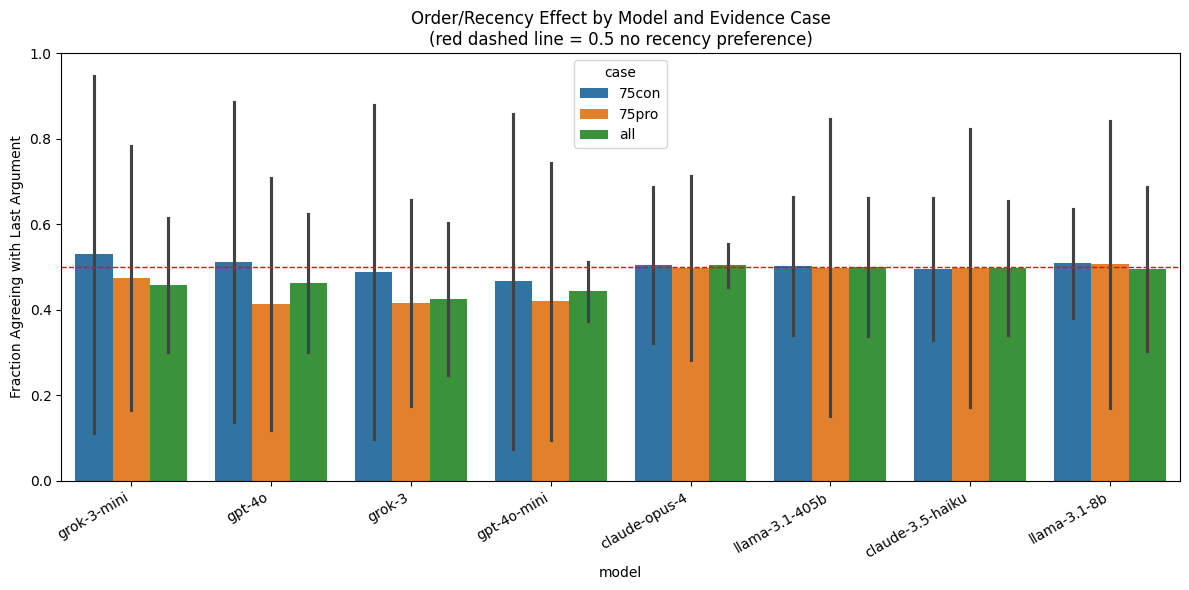

,model,case,agreed_with_last_pct,p_value_vs_50pct
6,claude-3.5-haiku,75con,0.661146,5.698970e-274
10,claude-3.5-haiku,75con,0.328160,2.020193e-118
18,claude-3.5-haiku,75pro,0.822192,0.000000e+00
26,claude-3.5-haiku,75pro,0.173239,0.000000e+00
34,claude-3.5-haiku,all,0.654361,3.043225e-170
42,claude-3.5-haiku,all,0.340998,1.089532e-189
4,claude-opus-4,75con,0.686074,0.000000e+00
11,claude-opus-4,75con,0.322909,3.234746e-122
21,claude-opus-4,75pro,0.712815,0.000000e+00
24,claude-opus-4,75pro,0.281980,1.072851e-186


In [2]:
order_df = pd.read_csv('../results/order_effects.csv')
order_df = order_df.sort_values(['case', 'agreed_with_last_pct'], ascending=[True, False]).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=order_df,
    x='model',
    y='agreed_with_last_pct',
    hue='case'
)
plt.axhline(0.5, linestyle='--', color='red', linewidth=1)
plt.ylim(0, 1)
plt.ylabel('Fraction Agreeing with Last Argument')
plt.title('Order/Recency Effect by Model and Evidence Case\n(red dashed line = 0.5 no recency preference)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

order_df[['model', 'case', 'agreed_with_last_pct', 'p_value_vs_50pct']].sort_values(['model', 'case'])